# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
##% title Imports
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import os
import pandas as pd

from neural_value_helpers import create_r_style_plot
import popy.config as cfg
from popy.config import PROJECT_PATH_LOCAL as PATH
from popy.config import COLORS as COLORS

PATH = cfg.PROJECT_PATH_LOCAL


In [2]:
##% Plotting Functions

# fontsize = 8
plt.rcParams.update({'font.size': 8})


def print_stats(stats_df):
    # print number of sessions per monkey, subregion, and hypothesis
    stats_summary = stats_df.groupby(['monkey', 'subregion', 'hypothesis']).size().reset_index(name='count')
    stats_summary = stats_summary.sort_values(by=['monkey', 'subregion', 'hypothesis'])

    # print in user-friendly format
    for (monkey, subregion), group in stats_summary.groupby(['monkey', 'subregion']):
        print(f"{monkey} - {subregion}:")
        n_sessions = len(stats_df[(stats_df['monkey'] == monkey) & (stats_df['subregion'] == subregion)])
        for _, row in group.iterrows():
            print(f"  {row['hypothesis']}: {row['count']} sessions ({row['count'] / n_sessions * 100:.1f}%)")
        print()  # Add a newline for better readability

    # now plot donut charts for each monkey and sessions

    fig2, axs = plt.subplots(1, 3, figsize=(5, 2))
    plt.rcParams.update({'font.size': 8})

    subregions = stats_summary['subregion'].unique()

    for s, subregion in enumerate(subregions):
        group = stats_summary[stats_summary['subregion'] == subregion]
        # sum count per monkey
        group = group.groupby('hypothesis').sum().reset_index()

        # order hypotheses as ['Foraging', 'RL simple', 'RL counterfactual', 'PROBLEM', 'none']
        ordered_hypotheses = ['Foraging', 'RL simple', 'RL counterfactual', 'PROBLEM', 'none']
        group = group.copy()  # Create a copy to avoid SettingWithCopyWarning
        group['hypothesis'] = pd.Categorical(group['hypothesis'], categories=ordered_hypotheses, ordered=True)
        group = group.sort_values('hypothesis')

        ax = axs[s]

        if not group.empty:
            # Get colors for each hypothesis
            colors = [COLORS[hypothesis] for hypothesis in group['hypothesis']]
            
            # Create donut chart with better percentage positioning
            wedges, texts, autotexts = ax.pie(group['count'], 
                                            labels=None,  # Remove labels from chart
                                            colors=colors,
                                            autopct='%1.1f%%',
                                            startangle=90,
                                            counterclock=False,
                                            pctdistance=1,  # Position percentages closer to edge
                                            wedgeprops=dict(alpha=.6, width=0.5))  # This creates the donut hole

            # Improve percentage text formatting
            for autotext in autotexts:
                autotext.set_color('black')
                autotext.set_fontsize(7)
                #autotext.set_weight('bold')
                autotext.set_bbox(dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.8, edgecolor='none'))

            # Add center circle for better donut appearance
            centre_circle = plt.Circle((0,0), 0.50, fc='white', edgecolor=COLORS[subregion], linewidth=2)
            ax.add_artist(centre_circle)
            # Add circle around (edge)
            centre_circle = plt.Circle((0,0), 1, fc='none', edgecolor=COLORS[subregion], linewidth=2)
            ax.add_artist(centre_circle)

            # Add title in the center
            ax.text(0, 0, f'{subregion}', ha='center', va='center', 
                    fontsize=8, weight='bold', color=COLORS[subregion])

            ax.set_title(f'KA & PO, n={group["count"].sum()}', fontsize=8, pad=10)
            
        else:
            # Hide subplot if no data
            ax.set_visible(False)


    fig1, axs = plt.subplots(2, 3, figsize=(5, 4), 
                            gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.1, 'wspace': 0.2})
    plt.rcParams.update({'font.size': 8})

    subregions = stats_summary['subregion'].unique()
    monkeys = stats_summary['monkey'].unique()

    for s, subregion in enumerate(subregions):
        for m, monkey in enumerate(monkeys):
            group = stats_summary[(stats_summary['subregion'] == subregion) & 
                                  (stats_summary['monkey'] == monkey)]
            # sum count per monkey
            group = group.groupby('hypothesis').sum().reset_index()

            # order hypotheses as ['Foraging', 'RL simple', 'RL counterfactual', 'PROBLEM', 'none']
            ordered_hypotheses = ['Foraging', 'RL simple', 'RL counterfactual', 'PROBLEM', 'none']
            group = group.copy()  # Create a copy to avoid SettingWithCopyWarning
            group['hypothesis'] = pd.Categorical(group['hypothesis'], categories=ordered_hypotheses, ordered=True)
            group = group.sort_values('hypothesis')

            ax = axs[m, s]

            if not group.empty:
                # Get colors for each hypothesis
                colors = [COLORS[hypothesis] for hypothesis in group['hypothesis']]
                
                # Create donut chart with better percentage positioning
                wedges, texts, autotexts = ax.pie(group['count'], 
                                                labels=None,  # Remove labels from chart
                                                colors=colors,
                                                autopct='%1.1f%%',
                                                startangle=90,
                                                counterclock=False,
                                                pctdistance=1,  # Position percentages closer to edge
                                                wedgeprops=dict(alpha=.6, width=0.5))  # This creates the donut hole

                # Improve percentage text formatting
                for autotext in autotexts:
                    autotext.set_color('black')
                    autotext.set_fontsize(7)
                    #autotext.set_weight('bold')
                    autotext.set_bbox(dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.8, edgecolor='none'))

                # Add center circle for better donut appearance
                centre_circle = plt.Circle((0,0), 0.50, fc='white', edgecolor=COLORS[subregion], linewidth=2)
                ax.add_artist(centre_circle)
                # Add circle around (edge)
                centre_circle = plt.Circle((0,0), 1, fc='none', edgecolor=COLORS[subregion], linewidth=2)
                ax.add_artist(centre_circle)

                # Add title in the center
                ax.text(0, 0, f'{subregion}', ha='center', va='center', 
                        fontsize=8, weight='bold', color=COLORS[subregion])

                ax.set_title(f'{monkey}, n={group["count"].sum()}', fontsize=8, pad=10)

            else:
                # Hide subplot if no data
                ax.set_visible(False)
    
    # Create legend using all possible hypotheses
    ordered_hypotheses = ['Foraging', 'RL simple', 'RL counterfactual', 'PROBLEM', 'none']
    legend_colors = [COLORS[hypothesis] for hypothesis in ordered_hypotheses]
    legend_handles = [plt.Rectangle((0,0),1,1, facecolor=color) for color in legend_colors]
    
    # Add legend to the figure
    fig1.legend(legend_handles, ordered_hypotheses, loc='center left', bbox_to_anchor=(1, 0.5))
    fig2.legend(legend_handles, ordered_hypotheses, loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.tight_layout()  # Re-enabled tight_layout for better spacing
    return fig1, fig2


def plot_session_wise(results_df_mean, monkeys='two'):
    # Create the figure
    # Create the plots
    plt.rcParams.update({'font.size': 8})

    subregions = results_df_mean['subregion'].unique()
    n_subregions = len(subregions)
    
    if monkeys == 'both':
        # 1x3 grid (or 1xN for N subregions)
        n_rows, n_cols = 1, n_subregions
        fig = plt.figure(figsize=(3 * n_cols, 2))
        
        # Create main grid
        gs_main = gridspec.GridSpec(n_rows, n_cols, figure=fig)
        
        axs = []
        
        for s, subregion in enumerate(subregions):
            group = results_df_mean[results_df_mean['subregion'] == subregion]
            
            # Create subdivided grid for this subplot
            gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, gs_main[0, s], 
                                                     wspace=0.1, hspace=0.1)
            
            # Create the two sub-axes
            ax1 = fig.add_subplot(gs_sub[0, 0])
            ax2 = fig.add_subplot(gs_sub[0, 1], sharey=ax1)
            
            # Within target plot
            create_r_style_plot(ax1, 
                            group.loc[group['type'] == 'within'], 
                            'feedback', 'dV_neural', 'Within target')
            
            # Alter target plot  
            create_r_style_plot(ax2, 
                            group.loc[group['type'] == 'alter'], 
                            'feedback', 'dV_neural', 'Alter target')
            
            # remove y axis, ticks and labels from 2nd plot
            ax2.yaxis.set_visible(False)
            # Add title for this subregion
            ax1.set_title(f'{subregion}', fontsize=8)
            ax2.set_title(f'{subregion}', fontsize=8)
            axs.append([ax1, ax2])
    
    else:
        # 2x3 grid (or 2xN for N subregions)
        monkeys_list = results_df_mean['monkey'].unique()
        n_monkeys = len(monkeys_list)
        n_rows, n_cols = n_monkeys, n_subregions
        
        fig = plt.figure(figsize=(5 * n_cols, 3 * n_rows))
        
        # Create main grid
        gs_main = gridspec.GridSpec(n_rows, n_cols, figure=fig)
        
        axs = []
        
        for m, monkey in enumerate(monkeys_list):
            row_axs = []
            for s, subregion in enumerate(subregions):
                group = results_df_mean[(results_df_mean['monkey'] == monkey) & 
                                      (results_df_mean['subregion'] == subregion)]
                
                # Create subdivided grid for this subplot
                gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, gs_main[m, s], 
                                                         wspace=0.1, hspace=0.1)
                
                # Create the two sub-axes
                ax1 = fig.add_subplot(gs_sub[0, 0])
                ax2 = fig.add_subplot(gs_sub[0, 1], sharey=ax1)
                
                # Within target plot
                create_r_style_plot(ax1, 
                                group.loc[group['type'] == 'within'], 
                                'feedback', 'dV_neural', 'Within target')
                
                # Alter target plot
                create_r_style_plot(ax2, 
                                group.loc[group['type'] == 'alter'], 
                                'feedback', 'dV_neural', 'Alter target')
                
                # Add title for this subplot
                #gs_sub.suptitle(f'{monkey} - {subregion}', fontsize=12, y=0.98)
                
                row_axs.append([ax1, ax2])
            axs.append(row_axs)

    return fig, axs 


def create_2d_scatter_with_marginals(data, x_type='within', y_type='alter', 
                                   session_col='session', feedback_col='feedback',
                                   value_col='dV_neural', title=None, palette=None,
                                paper_format=False):
    """
    Create a 2D scatter plot with marginal distributions
    
    Args:
        data: DataFrame with the data
        x_type: type value for x-axis (e.g., 'within')
        y_type: type value for y-axis (e.g., 'alter')
        session_col: column name for session identifier
        feedback_col: column name for feedback (0/1)
        value_col: column name for the neural values
        title: plot title
        palette: color palette dict
        figsize: figure size
        paper_format: whether to use paper formatting
    """
    
    if palette is None:
        palette = {'0': 'tab:red', '1': 'tab:green'}
    
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        s = 15
        h = 2.5 * 5.3/6
        w = 2.5 * 5.3/6
        lw = 0.4
    else:
        plt.rcParams.update({'font.size': 12})
        s = 30
        lw = 0.8
        h, w = 6, 6

    # Trick: if signif is not a column, add all trues
    if 'signif' not in data.columns:
        data['signif'] = True

    # Prepare data for scatter plot
    # Get x-axis data (e.g., within target)
    x_data = data[data['type'] == x_type].copy()
    # Get y-axis data (e.g., alter target) 
    y_data = data[data['type'] == y_type].copy()
    
    # Create scatter data by merging on session and feedback
    scatter_data = []
    
    count_all, count_within_signif, count_within_alter_signif = 0, 0, 0
    for session in data[session_col].unique():
        count_all += 1
        signif_same = x_data[(x_data[session_col] == session) & (x_data[feedback_col] == 1)]['signif'].values[0]
        signif_alter = y_data[(y_data[session_col] == session) & (y_data[feedback_col] == 1)]['signif'].values[0]
        for feedback in data[feedback_col].unique():
            x_val = x_data[(x_data[session_col] == session) & 
                          (x_data[feedback_col] == feedback)][value_col].values
            y_val = y_data[(y_data[session_col] == session) & 
                          (y_data[feedback_col] == feedback)][value_col].values
            
            if len(x_val) > 0 and len(y_val) > 0:
                scatter_data.append({
                    'x': x_val[0],
                    'y': y_val[0], 
                    'feedback': str(feedback),
                    'session': session,
                    'signif_same': signif_same,
                    'signif_alter': signif_alter
                })
    
    scatter_df = pd.DataFrame(scatter_data)

    # Create figure with gridspec for marginal plots
    fig = plt.figure(figsize=(w, h))
    
    # Define the grid: main plot, top histogram, right histogram
    gs = fig.add_gridspec(3, 3, 
                         width_ratios=[1, 4, 1], 
                         height_ratios=[1, 4, 1],
                         hspace=0.05, wspace=0.05)
    
    # Main scatter plot
    ax_main = fig.add_subplot(gs[1, 1])
    
    # Marginal plots
    ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
    
    # Create scatter plot
    for feedback in ['0', '1']:
        for signif_same in [True, False]:
            for signif_alter in [True, False]:
                # Filter data for this feedback and significance
                mask = (scatter_df['feedback'] == feedback) & \
                       (scatter_df['signif_same'] == signif_same) & \
                       (scatter_df['signif_alter'] == signif_alter)
                
                if mask.sum() > 0:
                    if signif_same is False:
                        ax_main.scatter(scatter_df.loc[mask, 'x'], 
                                   scatter_df.loc[mask, 'y'],
                                   c='black',
                                   alpha=0.3, 
                                   linewidths=lw*2,
                                   s=s/2,
                                   marker='x',
                                   zorder=0,
                                   )
                    else:
                        ax_main.scatter(scatter_df.loc[mask, 'x'], 
                                   scatter_df.loc[mask, 'y'],
                                   c=palette[feedback] if signif_alter else 'white',
                                   alpha=0.7, 
                                   s=s,
                                   edgecolor='black' if signif_alter else palette[feedback], 
                                   linewidth=lw,
                                   label=f'{"Unrewarded" if feedback == "0" else "Rewarded"}',
                                   zorder=10)
        
    
    # Add connecting lines between paired points (same session)
    if session_col == 'session':
        for session in scatter_df['session'].unique():
            session_data = scatter_df[scatter_df['session'] == session]
            if len(session_data) == 2:  # Both feedback conditions present
                x_vals = session_data['x'].values
                y_vals = session_data['y'].values
                ax_main.plot(x_vals, y_vals, '-', color='gray', alpha=0.3, 
                            linewidth=lw, zorder=0)
    
    # Add diagonal reference line
    lims = [
        np.min([ax_main.get_xlim(), ax_main.get_ylim()]),
        np.max([ax_main.get_xlim(), ax_main.get_ylim()]),
    ]
    ax_main.plot(lims, lims, 'k--', alpha=0.5, zorder=0, linewidth=lw)
    
    # Add zero lines
    ax_main.axhline(0, linestyle='--', alpha=0.5, color='black', linewidth=lw, zorder=0)
    ax_main.axvline(0, linestyle='--', alpha=0.5, color='black', linewidth=lw, zorder=0)
    
    # Set labels
    ax_main.set_xlabel(f'Within-target change\nin neural value')
    ax_main.set_ylabel(f'Across-target change\nin neural value')
    #ax_main.legend(frameon=False)
    
    # Create marginal distributions (top - x-axis distribution)
    for fb_id, feedback in enumerate(['0', '1']):
        # X-axis marginal (top)
        x_feedback_data = x_data[x_data[feedback_col] == int(feedback)][value_col].values
        if len(x_feedback_data) > 0:
            # Violin plot
            density = stats.gaussian_kde(x_feedback_data)
            x_range = np.linspace(x_feedback_data.min() - 0.1 * np.ptp(x_feedback_data),
                                 x_feedback_data.max() + 0.1 * np.ptp(x_feedback_data), 200)
            density_values = density(x_range)
            density_values = density_values / density_values.max() * 0.8
            
            ax_top.fill_between(x_range, 0, density_values, 
                               color=palette[feedback], alpha=0.3, 
                               edgecolor='black', linewidth=lw)
            
            # Box plot
            bp = ax_top.boxplot([x_feedback_data], positions=[0.4-fb_id*.2], widths=0.2, 
                               patch_artist=True, vert=False,
                               boxprops=dict(alpha=0.7, facecolor=palette[feedback]),
                               showfliers=False, medianprops=dict(color='black'))
    
    # Calculate significance for X-axis marginal
    x_data_pos = x_data[x_data['feedback'] == 1][value_col].values
    x_data_neg = x_data[x_data['feedback'] == 0][value_col].values
    U_x, p_value_x = stats.mannwhitneyu(x_data_pos, x_data_neg, alternative='two-sided')
    
    # Add significance line and p-value for X-axis marginal (top)
    # Position line between the box plot centers
    x_pos_center = np.median(x_data_pos)  # Center of positive feedback data
    x_neg_center = np.median(x_data_neg)  # Center of negative feedback data
    y_line = 0.9  # Position of the line
    line_height = 0.05  # Height of the brackets
    
    # Draw horizontal line between the medians
    ax_top.plot([x_neg_center, x_pos_center], [y_line, y_line], 'k-', linewidth=lw)
    
    # Format p-value with significance stars and sample size
    n_total = len(x_data_pos) + len(x_data_neg)
    if p_value_x > 0.05:
        p_text_x = f'n.s.'
    elif p_value_x <= 0.001:
        p_text_x = f'***'
    elif p_value_x <= 0.01:
        p_text_x = f'**'
    elif p_value_x <= 0.05:
        p_text_x = f'*'
    
    ax_top.text((x_neg_center + x_pos_center) / 2, y_line * 1.1, p_text_x, 
                ha='center', va='bottom', fontsize=plt.rcParams['font.size']-1)

    # Y-axis marginal (right)
    for fb_id, feedback in enumerate(['0', '1']):
        y_feedback_data = y_data[y_data[feedback_col] == int(feedback)][value_col].values
        if len(y_feedback_data) > 0:
            # Violin plot
            density = stats.gaussian_kde(y_feedback_data)
            y_range = np.linspace(y_feedback_data.min() - 0.1 * np.ptp(y_feedback_data),
                                 y_feedback_data.max() + 0.1 * np.ptp(y_feedback_data), 200)
            density_values = density(y_range)
            density_values = density_values / density_values.max() * 0.8
            
            ax_right.fill_betweenx(y_range, 0, density_values, 
                                  color=palette[feedback], alpha=0.3, 
                                  edgecolor='black', linewidth=lw)
            
            # Box plot
            bp = ax_right.boxplot([y_feedback_data], positions=[0.4-fb_id*.2], widths=0.2, 
                                 patch_artist=True, vert=True,
                                 boxprops=dict(alpha=0.7, facecolor=palette[feedback]),
                                 showfliers=False, medianprops=dict(color='black'))
    
    # Calculate significance for Y-axis marginal
    y_data_pos = y_data[y_data['feedback'] == 1][value_col].values
    y_data_neg = y_data[y_data['feedback'] == 0][value_col].values
    U_y, p_value_y = stats.mannwhitneyu(y_data_pos, y_data_neg, alternative='two-sided')

    # Add significance line and p-value for Y-axis marginal (right)
    # Position line between the box plot centers
    y_pos_center = np.median(y_data_pos)  # Center of positive feedback data
    y_neg_center = np.median(y_data_neg)  # Center of negative feedback data
    x_line = 0.9  # Position of the line
    line_width = 0.05  # Width of the brackets
    
    # Draw vertical line between the medians
    ax_right.plot([x_line, x_line], [y_neg_center, y_pos_center], 'k-', linewidth=lw)
    
    # Format p-value with significance stars and sample size
    if p_value_y > 0.05:
        p_text_y = f'n.s.'
    elif p_value_y <= 0.001:
        p_text_y = f'***'
    elif p_value_y <= 0.01:
        p_text_y = f'**'
    elif p_value_y <= 0.05:
        p_text_y = f'*'
    
    ax_right.text(x_line*1.3, (y_neg_center + y_pos_center) / 2, p_text_y, 
                  ha='center', va='center', rotation=90, fontsize=plt.rcParams['font.size']-1)
    
    # Add zero lines to marginal plots
    ax_top.axvline(0, linestyle='--', alpha=0.5, color='black', linewidth=lw, zorder=0)
    ax_right.axhline(0, linestyle='--', alpha=0.5, color='black', linewidth=lw, zorder=0)
    
    # Format marginal plots
    ax_top.set_xlim(ax_main.get_xlim())
    ax_top.set_ylim(0, 1)
    ax_top.set_yticks([])
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_top.spines['left'].set_visible(False)
    ax_top.tick_params(labelbottom=False)
    
    ax_right.set_ylim(ax_main.get_ylim())
    ax_right.set_xlim(0, 1)
    ax_right.set_xticks([])
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)
    ax_right.spines['bottom'].set_visible(False)
    ax_right.tick_params(labelleft=False)
    
    # Format main plot
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    
    n_total = len(np.unique(x_data['session']))  # Number of unique sessions
    plt.suptitle(f'n= {n_total}')

    return fig, ax_main, ax_top, ax_right


In [3]:
def get_data():
    path = os.path.join(cfg.PROJECT_PATH_LOCAL, 'notebooks', 'population_decoding', 'results', 'behav_neural_value_across_target', 'behav.pkl')

    results_df = pd.read_pickle(path)
    # sort by monkey session trial_id target type
    results_df = results_df.sort_values(by=['monkey', 'session', 'subregion', 'trial_id'])
    results_df = results_df.dropna()
    return results_df

def merge_alter_values(results_df):
    """Merge 'alter' type rows by averaging their values for each trial, so that we only have one."""
    # for each (monkey, session, subregion, trial_id), replace the two 'type'=='alter' rows with one that has these attributes, and averages everything else

    results_df_within = results_df[results_df['type'] == 'within']
    results_df_alter = results_df[results_df['type'] == 'alter']

    results_df_alter_means = []
    for (monkey, session, subregion, trial_id), group in results_df_alter.groupby(['monkey', 'session', 'subregion', 'trial_id']):
        mean_row = {}
        mean_row['monkey'] = monkey
        mean_row['session'] = session
        mean_row['subregion'] = subregion
        mean_row['trial_id'] = trial_id
        mean_row['type'] = 'alter'
        mean_row['feedback'] = group['feedback'].values[0]  # or .mean() if you want the average
        mean_row['dV_neural'] = group['dV_neural'].mean()

        results_df_alter_means.append(mean_row)
    results_df_alter_means = pd.DataFrame(results_df_alter_means)

    # Combine the two dataframes
    results_df_combined = pd.concat([results_df_within[results_df_alter_means.columns.tolist()], results_df_alter_means], ignore_index=True)

    # feedback is int

    results_df = results_df_combined
    results_df = results_df.sort_values(by=['monkey', 'session', 'subregion', 'trial_id'])

    # reset index
    results_df = results_df.reset_index(drop=True)

    return results_df

def extract_hypothesis(res):
    stats_df = []
    for (monkey, session, subregion), group in res.groupby(['monkey', 'session', 'subregion']):
        dVs_pos_same = group[(group['feedback'] == 1) & (group['type'] == 'within')]['dV_neural'].values
        dVs_neg_same = group[(group['feedback'] == 0) & (group['type'] == 'within')]['dV_neural'].values
        U_same, p_value_same = stats.mannwhitneyu(dVs_pos_same, dVs_neg_same, alternative='two-sided')

        dVs_pos_alter = group[(group['feedback'] == 1) & (group['type'] == 'alter')]['dV_neural'].values
        dVs_neg_alter = group[(group['feedback'] == 0) & (group['type'] == 'alter')]['dV_neural'].values
        U_alter, p_value_alter = stats.mannwhitneyu(dVs_pos_alter, dVs_neg_alter, alternative='two-sided')

        stats_df.append({
            'monkey': monkey,
            'session': session,
            'subregion': subregion,
            #'hypothesis': hypothese,
            'p_value_same': p_value_same,
            'U_same': U_same,
            'p_value_alter': p_value_alter,
            'U_alter': U_alter,
        })
    # Convert stats to DataFrame
    stats_df = pd.DataFrame(stats_df)

    # FDR correction for p-values per monkey and subregion
    #stats_df = add_corrected_pvals(stats_df)

    # get hypothesis based on p-values
    for i, row in stats_df.iterrows():
        if row['p_value_same'] < 0.05:
            if row['p_value_alter'] < 0.05:
                if row['U_alter'] > 0:
                    hypothese = 'Foraging'
                else:
                    hypothese = 'RL counterfactual'
            else:
                hypothese = 'RL simple'
        else:
            if row['p_value_alter'] < 0.05:
                hypothese = 'none'  # But actually PROBLEM
            else:
                hypothese = 'none'

        stats_df.at[i, 'hypothesis'] = hypothese

    return stats_df

def add_corrected_pvals(cpd_all):
    from statsmodels.stats.multitest import multipletests

    # Get p-value columns
    pval_cols = [col for col in cpd_all.columns if col.startswith('p_value') and not col.endswith('corrected')]

    # Create new columns for corrected p-values
    for col in pval_cols:
        cpd_all[f'{col}_corrected'] = np.nan

    # Apply correction within each group (monkey × subregion)
    for monkey in cpd_all.monkey.unique():
        for subregion in cpd_all.subregion.unique():
            # Get mask for this group
            group_mask = (cpd_all.monkey == monkey) & (cpd_all.subregion == subregion)
            
            # Extract p-values for this group
            group_pvals = cpd_all.loc[group_mask, pval_cols].values
            
            # Apply correction within this group
            rejected, pvals_corrected, _, _ = multipletests(
                group_pvals.flatten(), method='fdr_bh'
            )
            
            # Reshape back to original shape
            pvals_corrected = pvals_corrected.reshape(group_pvals.shape)
            
            # Write back corrected p-values
            for i, col in enumerate(pval_cols):
                cpd_all.loc[group_mask, f'{col}_corrected'] = pvals_corrected[:, i]

    ''' # Now use the corrected p-values
    pval_cols_corrected = [f'{col}_corrected' for col in pval_cols]'''

    return cpd_all


---
# Get data

In [4]:
# Get data
res = get_data()
res = merge_alter_values(res)

# normalize dV_neural within each monkey, session, subregion
res[f'dV_neural'] = res.groupby(['monkey', 'session', 'subregion'])[f'dV_neural'].transform(lambda x: (x - x.mean()) / x.std())
res

,monkey,session,subregion,trial_id,type,feedback,dV_neural
0,ka,010720,MCC,8,within,1,-0.147941
1,ka,010720,MCC,8,alter,1,-0.440085
2,ka,010720,MCC,9,within,1,0.554886
3,ka,010720,MCC,9,alter,1,0.351978
4,ka,010720,MCC,10,within,1,-0.625316
...,...,...,...,...,...,...,...
115373,po,310822,dLPFC,419,alter,0,-2.447534
115374,po,310822,dLPFC,420,within,1,1.042724
115375,po,310822,dLPFC,420,alter,1,0.435004
115376,po,310822,dLPFC,421,within,1,-0.714193


# See results

## Example session


In [5]:
import matplotlib.colors as mcolors

def RL_vs_forage_single_sess(ax=None, data=None, x_col=None, y_col=None, title=None, session_col='session', paper_format=False):
    """Create R-style plot with violin, box, and jittered points
    
    Args:
        ax: matplotlib axis
        data: DataFrame with the data
        x_col: column name for x-axis categories
        y_col: column name for y-axis values
        title: plot title
        session_col: column name for session identifier (optional, for connecting points)
    """
    palette = COLORS
    axis = ax
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        h = 2 
        w = 2
        s = 3

    else:
        plt.rcParams.update({'font.size': 18})
        h = 3  # in cm
        w = 4  # in cm
        s = 10
    
    # distribution of pos and neg feedback along neural value
    if axis is None:
        fig, ax = plt.subplots(1, 1, figsize=(w, h))

    # Get unique categories
    # sort by x_col
    data = data.copy().sort_values(by=x_col)
    categories = data[x_col].unique()
    x_positions = np.arange(len(categories))
    
    x_offset = .2
    s = 10
    lw = .4 
        
    '''# Create violin plots (distributions)
    violin_positions = []
    for i in range(len(categories)):
        if will_connect_lines and i == 0:
            # First group: distribution on left
            violin_positions.append(x_positions[i] - x_offset)
        else:
            # Default: distribution on right
            violin_positions.append(x_positions[i] + x_offset)
    
    # Create half violin plots (distributions) - flat side towards boxplot
    for i, cat in enumerate(categories):
        y_data = data.loc[data[x_col] == cat, y_col].values
        
        # Create violin plot data
        density = stats.gaussian_kde(y_data)
        
        # Create y range for the distribution
        y_min, y_max = y_data.min(), y_data.max()
        y_range = np.linspace(y_min - 0.1 * (y_max - y_min), 
                             y_max + 0.1 * (y_max - y_min), 200)
        density_values = density(y_range)
        
        # Normalize density values to desired width
        density_values = density_values / density_values.max() * 0.15
        
        # Determine which side the distribution should be on
        if will_connect_lines and i == 0:
            # First group: distribution on left (away from points/lines)
            x_dist = violin_positions[i] - density_values
            x_null = violin_positions[i]  + .05
        else:
            # Default: distribution on right (away from points)
            x_dist = violin_positions[i] + density_values
            x_null = violin_positions[i] - .05
        
        # Fill the half violin
        ax.fill_betweenx(y_range, x_null, x_dist, 
                        color=palette[cat], alpha=0.3, 
                        edgecolor='black', linewidth=2*lw)
    '''
    
    # Create boxplots - centered
    box_data = [data.loc[data[x_col] == cat, y_col].values for cat in categories]
    bp = ax.boxplot(box_data, positions=x_positions, widths=0.2, patch_artist=True,
                   boxprops=dict(alpha=0.7),
                   showfliers=False,
                   medianprops=dict(color='black'),
                   #whiskerprops=dict(linewidth=1.5),
                   #capprops=dict(linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='black', markersize=3, alpha=0.5))
    
    # Color the boxes
    colors = [palette[cat] for cat in categories]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Store jitter positions for connecting lines
    jitter_positions = {}
    
    # Add jittered points
    for i, cat in enumerate(categories):
        y_data = data.loc[data[x_col] == cat, y_col].values
        colors = [palette[cat]] * len(y_data)
        
        # Default: points on left
        x_jitter = np.random.normal(x_positions[i] - x_offset, 0.02, size=len(y_data))
        
        ax.scatter(x_jitter, y_data, alpha=0.6, s=s, c=colors,
                   edgecolor='black', linewidth=lw)
        
        # Store jitter positions if we need to connect points
        if session_col is not None:
            session_data = data.loc[data[x_col] == cat, session_col].values
            jitter_positions[cat] = dict(zip(session_data, zip(x_jitter, y_data)))
    
    
    # Perform t-test and add significance
    if len(categories) == 2:
        group1_data = data.loc[data[x_col] == categories[0], y_col]
        group2_data = data.loc[data[x_col] == categories[1], y_col]
        #_, p_value = stats.ttest_ind(group1_data, group2_data)
        _, p_value = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

        
        # Position for significance bar
        y_max = data[y_col].max()
        y_pos = y_max + 0.1 * abs(y_max)
        
        # Add significance annotation
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'
        
        # Add the bar and text for p-value
        ax.plot([0, 1], [y_pos, y_pos], '-k', lw=2*lw)
        ax.text(0.5, y_pos + 0.02 * abs(y_max), f'{significance} (n={len(group1_data)})', 
                ha='center', va='bottom', fontsize=8)
    
    # Formatting
    ax.axhline(0, linestyle='--', alpha=0.7, color='black', lw=2*lw, zorder=0)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Unrewarded', 'Rewarded'], rotation=20)
    ax.set_ylabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$', fontsize=8)
    ax.set_xlabel('')
    ax.set_title(title, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

    if axis is None:
        return fig, ax
    else:
        return ax



In [6]:
import matplotlib.colors as mcolors


def RL_vs_forage_single_sess_horizontal(ax=None, data=None, x_col=None, y_col=None, title=None, session_col='session', paper_format=False):
    """Create R-style plot with box and jittered points (horizontal version)
    
    Args:
        ax: matplotlib axis
        data: DataFrame with the data
        x_col: column name for x-axis categories (now on y-axis)
        y_col: column name for values (now on x-axis)
        title: plot title
        session_col: column name for session identifier
    """
    palette = COLORS
    axis = ax
    if paper_format:
        fontsize = 8
        h = 2 
        w = 2
        s = 15
    else:
        fontsize = 18

        h = 3
        w = 4
        s = 10

    if axis is None:
        fig, ax = plt.subplots(1, 1, figsize=(w, h))

    data = data.copy().sort_values(by=x_col)
    categories = data[x_col].unique()
    y_positions = [0, .5]
    
    x_offset = .4
    lw = .4 
        
    # Create boxplots (horizontal)
    box_data = [data.loc[data[x_col] == cat, y_col].values for cat in categories]
    bp = ax.boxplot(box_data, positions=y_positions, widths=0.5, patch_artist=True,
                    boxprops=dict(alpha=0.7),
                    showfliers=False,
                    medianprops=dict(color='black'),
                    flierprops=dict(markersize=3, alpha=0.5),
                    vert=False)  # <-- horizontal

    # Color the boxes
    colors = [palette[cat] for cat in categories]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    # Store jitter positions
    jitter_positions = {}
    # If color is a string like 'red' or hex '#ff0000'
    base_rgba = mcolors.to_rgba(color, alpha=.5)
    # Darken by mixing with black (multiply RGB values by 0.7 to make it darker)
    edge_color = (base_rgba[0] * 0.7, base_rgba[1] * 0.7, base_rgba[2] * 0.7, 1.0)

    # Add jittered points (horizontal scatter)
    for i, cat in enumerate(categories):
        x_data = data.loc[data[x_col] == cat, y_col].values
        # If color is a string like 'red' or hex '#ff0000'
        base_rgba = mcolors.to_rgba(palette[cat], alpha=.5)
        # Darken by mixing with black (multiply RGB values by 0.7 to make it darker)
        edge_color = (base_rgba[0] * 0.7, base_rgba[1] * 0.7, base_rgba[2] * 0.7, 1.0)
        y_jitter = np.random.normal(-1, 0.15, size=len(x_data))
        
        # Generate random zorder values for each point
        zorder_values = np.random.uniform(10, 1000, size=len(x_data))
        
        # Plot each point individually with its own random zorder
        for x_val, y_val, z_val in zip(x_data, y_jitter, zorder_values):
            scatter = ax.scatter(x_val, y_val, s=s, facecolors=base_rgba, edgecolors=edge_color, linewidth=.5, zorder=z_val)

        if session_col is not None:
            session_data = data.loc[data[x_col] == cat, session_col].values
            jitter_positions[cat] = dict(zip(session_data, zip(x_data, y_jitter)))

    # Significance test
    if len(categories) == 2:
        group1_data = data.loc[data[x_col] == categories[0], y_col]
        group2_data = data.loc[data[x_col] == categories[1], y_col]
        _, p_value = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

        # Calculate mean positions for significance line
        mean1 = group1_data.mean()
        mean2 = group2_data.mean()
        
        # Get y positions for the categories
        y1 = y_positions[0]
        y2 = y_positions[1]
        
        # Position significance line above the plots
        line_height = max(y_positions) + 0.8
        
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'

        # Add horizontal significance line spanning between box means
        ax.plot([mean1, mean2], [line_height, line_height], '-k', lw=2*lw)
        # Add vertical lines connecting to boxes
        ax.plot([mean1, mean1], [line_height - 0.1, line_height], '-k', lw=2*lw)
        ax.plot([mean2, mean2], [line_height - 0.1, line_height], '-k', lw=2*lw)
        # Add significance text at the center
        ax.text((mean1 + mean2) / 2, line_height + 0.05, f'{significance} (n={len(group1_data)})',
                va='bottom', ha='center', fontsize=fontsize)

    # Formatting
    ax.axhline(-1, linestyle='-', alpha=1, color='black', lw=4*lw, zorder=1)

    vline_bottom = min(y_positions) - 1
    vline_top = max(y_positions) + 0.5  # stay below significance line
    ax.vlines(0, vline_bottom, vline_top, linestyle='-', color='black', lw=1, zorder=0)

    ax.set_yticks([])
    ax.set_xlabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$', fontsize=fontsize)
    ax.tick_params(axis='x', length=0)  # Remove x tick markers, keep labels

    ax.set_ylabel('')

    ax.set_title(title, fontsize=fontsize)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)

    if axis is None:
        return fig, ax
    else:
        return ax


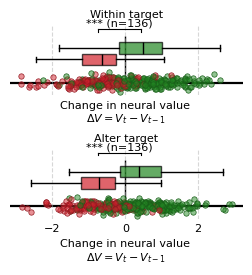

In [7]:
results_df_temp = res[(res['session'] == '210322') & (res['subregion'] == 'MCC')]

# Create the figure
fig, axs = plt.subplots(2, 1, figsize=(3, 2.5), sharex=True, gridspec_kw={'height_ratios': [1, 1], 'hspace': .8})

# Create the plots
palette = {'0': 'tab:red', '1': 'tab:green'}

# Within target plot
RL_vs_forage_single_sess_horizontal(axs[0],
                   results_df_temp.loc[results_df_temp['type'] == 'within'], 
                   'feedback', 'dV_neural', paper_format=True)
axs[0].set_title('Within target', fontsize=8)

# Alter target plot
RL_vs_forage_single_sess_horizontal(axs[1], 
                   results_df_temp.loc[results_df_temp['type'] == 'alter'],
                   'feedback', 'dV_neural', paper_format=True)
axs[1].set_title('Alter target', fontsize=8)

# save svg
fig.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'single_session_ka_21322_mcc.svg'), 
            bbox_inches='tight', dpi=300, transparent=True)

## Session-wise

In [8]:
# get mean of trials (i.e. mean of all trials in a session) for each monkey, session, subregion, feedback, type
results_df_mean = []
for (monkey, session, subregion, type_, feedback), group in res.groupby(['monkey', 'session', 'subregion', 'type', 'feedback']):
    # get mean of dV_neural, drop trial_id
    row_to_add = {}
    row_to_add['monkey'] = monkey
    row_to_add['session'] = session
    row_to_add['subregion'] = subregion
    row_to_add['type'] = type_
    row_to_add['feedback'] = feedback
    row_to_add['dV_neural'] = group['dV_neural'].mean()
    row_to_add['signif'] = np.nan

    results_df_mean.append(row_to_add)
# to df
results_df_mean = pd.DataFrame(results_df_mean)

for (monkey, session, subregion, type_), group in res.groupby(['monkey', 'session', 'subregion', 'type']):
    # compute significantce
    dVs_pos = group[(group['feedback'] == 1) & (group['type'] == type_)]['dV_neural'].values
    dVs_neg = group[(group['feedback'] == 0) & (group['type'] == type_)]['dV_neural'].values
    U, p_value = stats.mannwhitneyu(dVs_pos, dVs_neg, alternative='two-sided')

    # add True to the significant column for this type
    results_df_mean.loc[(results_df_mean['monkey'] == monkey) & 
                        (results_df_mean['session'] == session) & 
                        (results_df_mean['subregion'] == subregion) & 
                        (results_df_mean['type'] == type_), 'signif'] = p_value < 0.05
results_df_mean

,monkey,session,subregion,type,feedback,dV_neural,signif
0,ka,010720,MCC,alter,0,-0.336859,True
1,ka,010720,MCC,alter,1,0.235260,True
2,ka,010720,MCC,within,0,-0.404189,True
3,ka,010720,MCC,within,1,0.266037,True
4,ka,010720,vLPFC,alter,0,-0.109351,False
...,...,...,...,...,...,...,...
835,po,310822,MCC,within,1,0.014094,False
836,po,310822,dLPFC,alter,0,0.001734,False
837,po,310822,dLPFC,alter,1,0.026553,False
838,po,310822,dLPFC,within,0,-0.043834,False


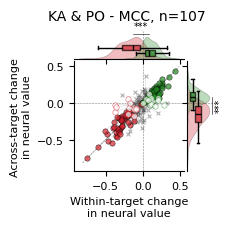

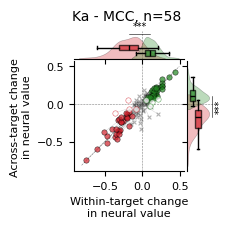

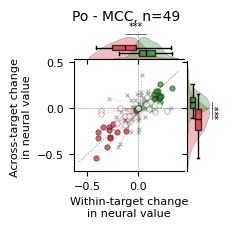

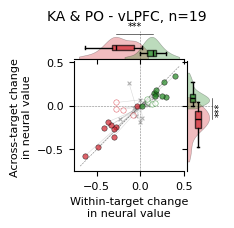

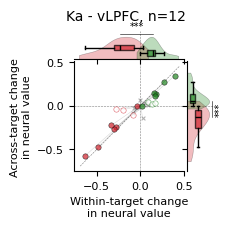

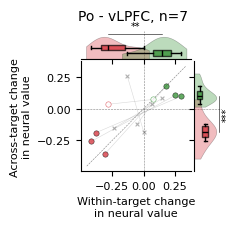

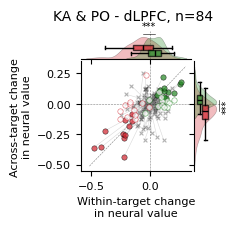

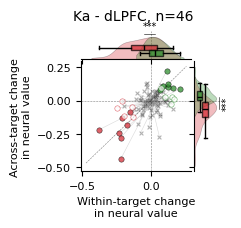

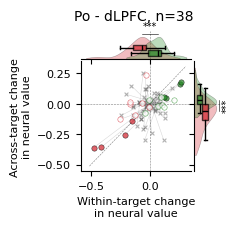

In [9]:
for subregion in results_df_mean['subregion'].unique():
    
    data = results_df_mean.loc[(results_df_mean['subregion'] == subregion)]
    fig, ax_main, ax_top, ax_right = create_2d_scatter_with_marginals(data, palette=COLORS, paper_format=True)
    fig.suptitle(f'KA & PO - {subregion}, n={len(np.unique(data.session))}', fontsize=10)

    fig.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', f'scatter_single_session_KAPO_{subregion}.svg'), bbox_inches='tight', dpi=300, transparent=True)

    for monkey in results_df_mean['monkey'].unique():
        data = results_df_mean.loc[(results_df_mean['subregion'] == subregion) & (results_df_mean['monkey'] == monkey)]
        fig, ax_main, ax_top, ax_right = create_2d_scatter_with_marginals(data, palette=COLORS, paper_format=True)
        fig.suptitle(f'{monkey.capitalize()} - {subregion}, n={len(np.unique(data.session))}', fontsize=10)

        fig.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', f'scatter_single_session_{monkey}_{subregion}.svg'), bbox_inches='tight', dpi=300, transparent=True)


## Print stats (all sessions)


ka - MCC:
  Foraging: 28 sessions (48.3%)
  RL simple: 4 sessions (6.9%)
  none: 26 sessions (44.8%)

ka - dLPFC:
  Foraging: 7 sessions (15.2%)
  RL simple: 5 sessions (10.9%)
  none: 34 sessions (73.9%)

ka - vLPFC:
  Foraging: 6 sessions (50.0%)
  RL simple: 3 sessions (25.0%)
  none: 3 sessions (25.0%)

po - MCC:
  Foraging: 14 sessions (28.6%)
  RL simple: 8 sessions (16.3%)
  none: 27 sessions (55.1%)

po - dLPFC:
  Foraging: 4 sessions (10.5%)
  RL simple: 7 sessions (18.4%)
  none: 27 sessions (71.1%)

po - vLPFC:
  Foraging: 3 sessions (42.9%)
  RL simple: 1 sessions (14.3%)
  none: 3 sessions (42.9%)



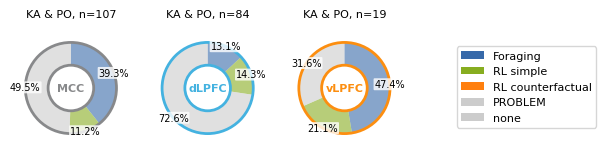

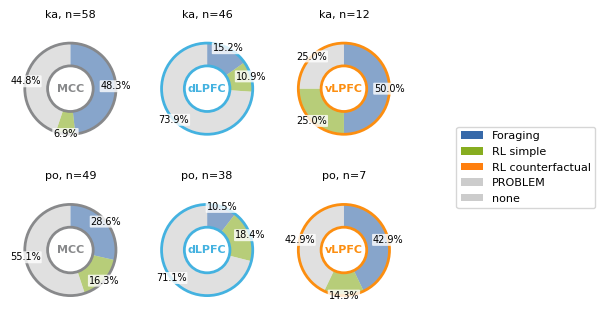

In [10]:
# Extract hypothesis info
stats_df = extract_hypothesis(res)

fig1, fig2 = print_stats(stats_df)
# save figure as svg

fig1.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'RL_forage_pies_both.svg'), format='svg', bbox_inches='tight', dpi=300, transparent=True)
fig2.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'RL_forage_pies_separate.svg'), format='svg', bbox_inches='tight', dpi=300, transparent=True)

ka - MCC:
  Foraging: 28 sessions (48.3%)
  RL simple: 4 sessions (6.9%)
  none: 26 sessions (44.8%)

ka - dLPFC:
  Foraging: 7 sessions (15.2%)
  RL simple: 5 sessions (10.9%)
  none: 34 sessions (73.9%)

ka - vLPFC:
  Foraging: 6 sessions (50.0%)
  RL simple: 3 sessions (25.0%)
  none: 3 sessions (25.0%)

po - MCC:
  Foraging: 14 sessions (28.6%)
  RL simple: 8 sessions (16.3%)
  none: 27 sessions (55.1%)

po - dLPFC:
  Foraging: 4 sessions (10.5%)
  RL simple: 7 sessions (18.4%)
  none: 27 sessions (71.1%)

po - vLPFC:
  Foraging: 3 sessions (42.9%)
  RL simple: 1 sessions (14.3%)
  none: 3 sessions (42.9%)

ka - MCC:
  Foraging: 28 sessions (48.3%)
  RL simple: 4 sessions (6.9%)
  none: 26 sessions (44.8%)

ka - dLPFC:
  Foraging: 7 sessions (15.2%)
  RL simple: 5 sessions (10.9%)
  none: 34 sessions (73.9%)

ka - vLPFC:
  Foraging: 6 sessions (50.0%)
  RL simple: 3 sessions (25.0%)
  none: 3 sessions (25.0%)

po - MCC:
  Foraging: 14 sessions (28.6%)
  RL simple: 8 sessions (16.3%

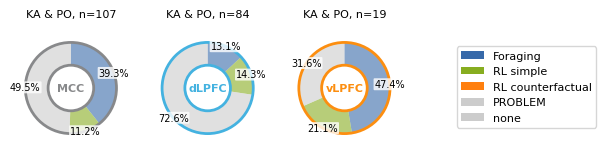

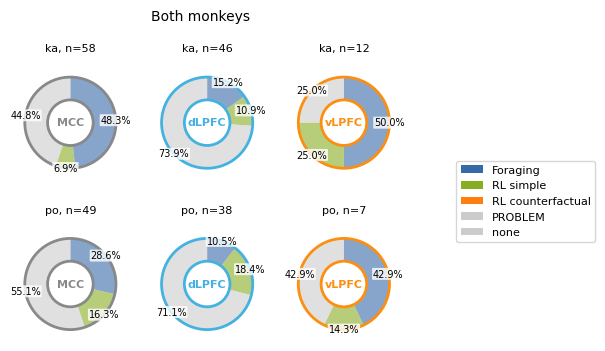

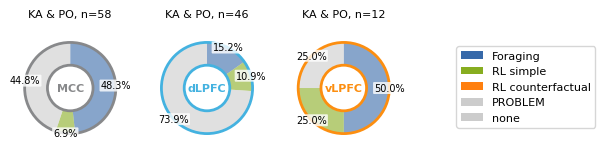

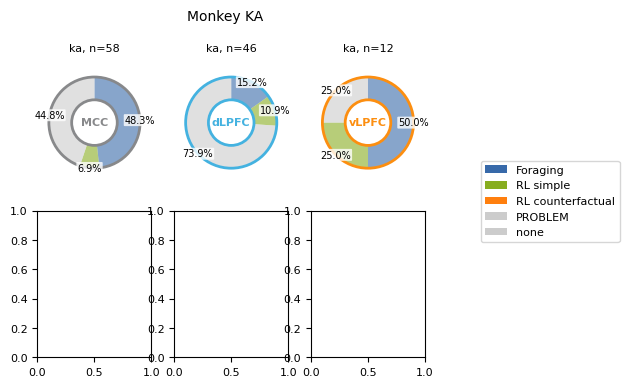

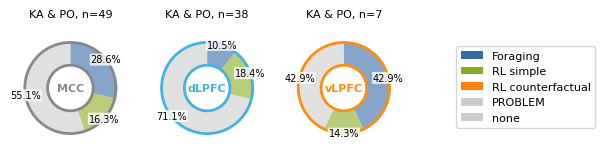

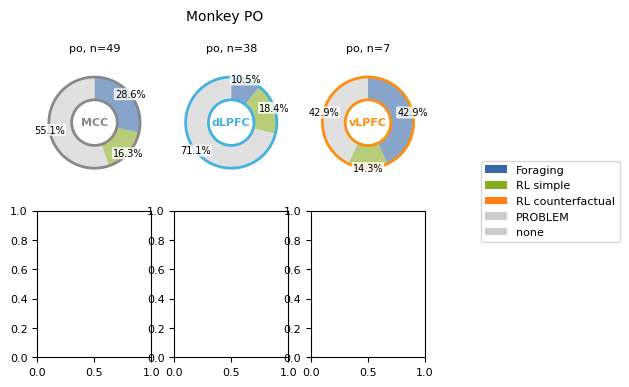

In [11]:
def print_stats_both(stats_df):     
    # Get data grouped by subregion and hypothesis
    stats_summary = stats_df.groupby(['monkey', 'subregion', 'hypothesis']).size().reset_index(name='count')     
    stats_summary = stats_summary.sort_values(by=['monkey', 'subregion', 'hypothesis'])      
    
    # Create horizontal bar plot showing proportions for each subregion
    fig, ax = plt.subplots(1, 1, figsize=(1.2, 1.5))
    plt.rcParams.update({'font.size': 8})
    
    subregions = ['MCC', 'dLPFC', 'vLPFC'][::-1]
    ordered_hypotheses = ['Foraging', 'RL simple', 'none', 'RL counterfactual', 'PROBLEM']
    
    # Calculate proportions and plot bars next to each other
    bar_width = 1.5
    bar_spacing = 0.2
    
    h_count = 0
    for h, hypothesis in enumerate(ordered_hypotheses):
        for s, subregion in enumerate(subregions):
            subregion_data = stats_summary[stats_summary['subregion'] == subregion]
            hypothesis_counts = subregion_data.groupby('hypothesis')['count'].sum()
            total_sessions = hypothesis_counts.sum()
            
            if hypothesis in hypothesis_counts:
                proportion = hypothesis_counts[hypothesis] / total_sessions
            else:
                proportion = 0
                
            print(f'Hypothesis: {hypothesis}, Proportions: {proportion}')
            if not proportion == 0:                
                # Plot bars for this hypothesis
                color = COLORS.get(hypothesis, 'gray')
                ax.barh(s - h_count * bar_spacing + bar_spacing, 
                        proportion * 100, 
                        height=bar_width/len(ordered_hypotheses), 
                    color=color, label=hypothesis, zorder=-h_count + 1, alpha=.8, edgecolor='grey', linewidth=0.5)
        h_count += 1
    
    # Customize the plot
    ax.set_yticks(range(len(subregions)))
    ax.set_yticklabels(subregions, rotation=90, va='center')
    ax.set_xlabel('Percent sessions\n(%)')

    ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=-1)
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Create legend
    legend_handles = [plt.Rectangle((0,0),1,1, facecolor=COLORS.get(hypothesis, 'gray'), alpha=0.8, edgecolor='grey', linewidth=0.5) 
                     for hypothesis in ordered_hypotheses if hypothesis in stats_summary['hypothesis'].values]
    legend_labels = [hypothesis for hypothesis in ordered_hypotheses 
                    if hypothesis in stats_summary['hypothesis'].values]
    
    fig.legend(legend_handles, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))


    return fig, ax


fig_bar_both, _ = print_stats(stats_df)
fig_bar_ka, _ = print_stats(stats_df.loc[stats_df['monkey'] == 'ka'])
fig_bar_po, _ = print_stats(stats_df.loc[stats_df['monkey'] == 'po'])

fig_bar_both.suptitle('Both monkeys', fontsize=10)
fig_bar_ka.suptitle('Monkey KA', fontsize=10)
fig_bar_po.suptitle('Monkey PO', fontsize=10)

# save figure
fig_bar_both.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'RL_forage_bars_both.svg'), format='svg', bbox_inches='tight', dpi=300, transparent=True)
fig_bar_ka.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'RL_forage_bars_ka.svg'), format='svg', bbox_inches='tight', dpi=300, transparent=True)
fig_bar_po.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'RL_forage_bars_po.svg'), format='svg', bbox_inches='tight', dpi=300, transparent=True)


In [12]:
stats_df

,monkey,session,subregion,p_value_same,U_same,p_value_alter,U_alter,hypothesis
0,ka,010720,MCC,5.855059e-09,25738.0,3.168890e-09,25853.0,Foraging
1,ka,010720,vLPFC,4.883022e-02,21386.0,1.135318e-01,20948.0,RL simple
2,ka,010822,MCC,1.095969e-02,14943.0,1.434250e-03,15487.0,Foraging
3,ka,010822,dLPFC,6.410728e-01,13187.0,3.697274e-02,14556.0,none
4,ka,010922,MCC,9.049953e-01,3858.0,5.917018e-01,3713.0,none
...,...,...,...,...,...,...,...,...
205,po,300322,vLPFC,2.654604e-01,10906.0,1.687231e-02,11806.0,none
206,po,300421,MCC,2.230176e-01,12538.0,7.561861e-02,12972.0,none
207,po,300421,dLPFC,2.921914e-02,13286.0,3.683331e-01,10890.0,RL simple
208,po,310822,MCC,2.934838e-01,12404.0,8.175246e-02,10223.0,none
